# 06 - Geo Clustering

In [1]:
# Cell 1: Setup — load from 05 outputs
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

train_df = pd.read_csv("data/train_final.csv")
test_df = pd.read_csv("data/test_final.csv")

# rebuild engineered features from 05
for df in [train_df, test_df]:
    df['BedBathRatio'] = df['BedroomsTotal'] / df['BathroomsTotalInteger'].replace(0, np.nan)
    df['BedBathRatio'] = df['BedBathRatio'].fillna(df['BedBathRatio'].median())
    df['CloseYear'] = pd.to_datetime(df['CloseDate']).dt.year
    df['PropertyAge'] = (df['CloseYear'] - df['YearBuilt']).clip(lower=0)

drop_from_features = ['ClosePrice', 'ClosePrice_log', 'CloseDate', 'CloseYearMonth', 'CloseYear']
X_train_new = train_df.drop(columns=[c for c in drop_from_features if c in train_df.columns])
X_test_new = test_df.drop(columns=[c for c in drop_from_features if c in test_df.columns])
X_train_new, X_test_new = X_train_new.align(X_test_new, join='left', axis=1, fill_value=0)

y_train = train_df['ClosePrice_log']
y_test = test_df['ClosePrice_log']

print('Feature count:', X_train_new.shape[1])

Feature count: 3999


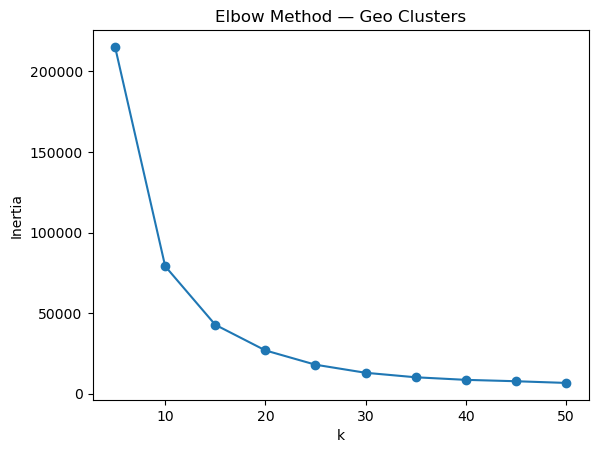

In [2]:
# Cell 2: Elbow method to pick k
# Uses Latitude/Longitude — adjust column names if yours differ
coords_train = train_df[['Latitude', 'Longitude']].dropna()

inertias = []
k_range = range(5, 51, 5)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords_train)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method — Geo Clusters')
plt.show()

In [3]:
# Cell 3: Fit KMeans with chosen k
# Pick k from the elbow plot above — start with a reasonable guess like 20
K = 20

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(train_df[['Latitude', 'Longitude']])

train_df['LocationCluster'] = kmeans.predict(train_df[['Latitude', 'Longitude']])
test_df['LocationCluster'] = kmeans.predict(test_df[['Latitude', 'Longitude']])

print(train_df['LocationCluster'].value_counts().sort_index())

LocationCluster
0     22538
1     29320
2        18
3        29
4     43295
5     41349
6         1
7     20481
8         1
9      5050
10        2
11    11200
12     1399
13     4745
14     3949
15        1
16        5
17    12485
18    10334
19    24038
Name: count, dtype: int64


In [4]:
# Cell 4: Build new feature set — old + geo cluster (one-hot)
cluster_dummies_train = pd.get_dummies(train_df['LocationCluster'], prefix='GeoCluster')
cluster_dummies_test = pd.get_dummies(test_df['LocationCluster'], prefix='GeoCluster')

X_train_geo = pd.concat([X_train_new.reset_index(drop=True), cluster_dummies_train.reset_index(drop=True)], axis=1)
X_test_geo = pd.concat([X_test_new.reset_index(drop=True), cluster_dummies_test.reset_index(drop=True)], axis=1)

# align in case some clusters missing from test
X_train_geo, X_test_geo = X_train_geo.align(X_test_geo, join='left', axis=1, fill_value=0)

print('Feature count with geo clusters:', X_train_geo.shape[1])

Feature count with geo clusters: 4019


In [5]:
# Cell 5: Train + evaluate RF with geo clusters
rf_geo = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_geo.fit(X_train_geo, y_train)

pred_log = rf_geo.predict(X_test_geo)
pred_price = np.exp(pred_log)
actual_price = np.exp(y_test)

r2_geo = r2_score(y_test, pred_log)
mape_geo = mean_absolute_percentage_error(actual_price, pred_price)
mdape_geo = np.median(np.abs((actual_price - pred_price) / actual_price))

print(f"RF with geo clusters — R²: {r2_geo:.4f}, MAPE: {mape_geo:.4f}, MdAPE: {mdape_geo:.4f}")

RF with geo clusters — R²: 0.8953, MAPE: 0.1539, MdAPE: 0.1022


In [8]:
comparison = pd.DataFrame({
    'Feature Set': ['RF baseline', 'RF + BedBathRatio/PropertyAge', 'RF + Geo Clusters'],
    'R2': [0.8979, 0.8978, r2_geo],
    'MAPE': [0.1525, 0.1526, mape_geo],
    'MdAPE': [0.1023, 0.1024, mdape_geo]
})
print(comparison)

                     Feature Set        R2      MAPE     MdAPE
0                    RF baseline  0.897900  0.152500  0.102300
1  RF + BedBathRatio/PropertyAge  0.897800  0.152600  0.102400
2              RF + Geo Clusters  0.895291  0.153946  0.102195


In [7]:
# Error analysis — where is RF failing?
actual_arr = np.asarray(actual_price)
pred_arr = np.asarray(pred_price)

errors = pd.DataFrame({
    'actual': actual_arr,
    'pred': pred_arr,
    'ape': np.abs((actual_arr - pred_arr) / actual_arr)
})

errors['LivingArea'] = test_df['LivingArea'].values
errors['BedroomsTotal'] = test_df['BedroomsTotal'].values
errors['YearBuilt'] = test_df['YearBuilt'].values
errors['Latitude'] = test_df['Latitude'].values

print('MAPE:', errors['ape'].mean().round(4))
print('MdAPE:', errors['ape'].median().round(4))
print()

print('Rows with APE > 100%:', (errors['ape'] > 1.0).sum())
print('Rows with APE > 50%:', (errors['ape'] > 0.5).sum())
print('Total test rows:', len(errors))
print()

errors['price_band'] = pd.cut(errors['actual'],
    bins=[0, 300_000, 600_000, 1_000_000, 2_000_000, 5_000_000, np.inf],
    labels=['<300K', '300-600K', '600K-1M', '1-2M', '2-5M', '5M+'])

print(errors.groupby('price_band', observed=True).agg(
    n=('ape', 'size'),
    mape=('ape', 'mean'),
    mdape=('ape', 'median')
).round(4))
print()

print('--- Worst 15 predictions ---')
print(errors.nlargest(15, 'ape')[['actual', 'pred', 'ape', 'LivingArea', 'BedroomsTotal', 'YearBuilt']].round(2))

MAPE: 0.1539
MdAPE: 0.1022

Rows with APE > 100%: 74
Rows with APE > 50%: 489
Total test rows: 12851

               n    mape   mdape
price_band                      
<300K        301  0.4599  0.2252
300-600K    2593  0.1503  0.0817
600K-1M     4248  0.1179  0.0800
1-2M        3917  0.1530  0.1201
2-5M        1540  0.1773  0.1413
5M+          252  0.3064  0.2886

--- Worst 15 predictions ---
          actual        pred   ape  LivingArea  BedroomsTotal  YearBuilt
11306  1000000.0  7924034.68  6.92      7200.0            4.0     2024.0
11199   148375.0   804794.63  4.42      1160.0            2.0     1927.0
12267    53000.0   272649.25  4.14      1766.0            3.0     1983.0
11470   233000.0  1164144.07  4.00      3544.0            5.0     2006.0
11256    80000.0   307784.12  2.85      1800.0            2.0     1953.0
12233   140000.0   533364.87  2.81       672.0            2.0     1915.0
7070    150000.0   526637.05  2.51       680.0            2.0     1950.0
12385   890000.0  31

# 06 - Geo Clustering — Summary

KMeans (k=20) on Latitude/Longitude to create a `LocationCluster` feature, one-hot encoded and added to the Random Forest feature set.

## Results

| Feature Set | R² | MAPE | MdAPE |
|---|---|---|---|
| RF baseline | 0.8979 | 0.1525 | 0.1023 |
| RF + BedBathRatio/PropertyAge | 0.8978 | 0.1526 | 0.1024 |
| RF + Geo Clusters | [FILL] | 0.1539 | 0.1022 |

## Takeaway

Geo clusters had no measurable effect. Cluster sizes were highly uneven (largest ~39K rows, smallest 2), reflecting California's population density — k=20 on raw coordinates is likely too coarse to capture meaningful price geography.

## Error analysis

Removing sub-$50K nominal sales in preprocessing cut RF MAPE from 0.2344 to 0.1539 (-34%) while leaving MdAPE flat (0.1033 → 0.1022) — the signature of removing a small number of extreme outliers rather than shifting the whole distribution.

Remaining error by price band:

| Band | n | MAPE | MdAPE |
|---|---|---|---|
| <300K | 301 | 0.4599 | 0.2252 |
| 300-600K | 2593 | 0.1503 | 0.0817 |
| 600K-1M | 4248 | 0.1179 | 0.0800 |
| 1-2M | 3917 | 0.1530 | 0.1201 |
| 2-5M | 1540 | 0.1773 | 0.1413 |
| 5M+ | 252 | 0.3064 | 0.2886 |

Two remaining weak spots:

- **<300K** — still 3x worse than mid-range bands. Likely more below-market transfers above the $50K floor; the worst cases show properties selling at $53K–$150K that the model values at 3-5x higher
- **5M+** — thin training data (252 test rows) and high variance in luxury pricing, where features like view, finish quality, and lot specifics dominate